# Lithuanian Informal-to-Formal Fine-Tuning Workflow

- smaller multilingual model,
- LoRA is used,
- very light default settings,
- optional quick subset mode,
- visible training progress bar,
- no `trl` dependency.


## 1. Install dependencies

In [74]:
%pip install torch transformers datasets peft accelerate sentencepiece safetensors matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
# Install CUDA-enabled PyTorch (matches the working cu128 build)
%pip uninstall -y torch torchvision torchaudio
%pip install torch==2.11.0+cu128 --index-url https://download.pytorch.org/whl/cu128
print('Installed CUDA-enabled PyTorch. Restart the kernel, then re-run from Cell 1.')


Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download-r2.pytorch.org/whl/cu128/torch-2.11.0%2Bcu128-cp314-cp314-win_amd64.whl.metadata (29 kB)
Using cached https://download-r2.pytorch.org/whl/cu128/torch-2.11.0%2Bcu128-cp314-cp314-win_amd64.whl (2771.0 MB)
Note: you may need to restart the kernel to use updated packages.
Installed CUDA-enabled PyTorch. Restart the kernel, then re-run from Cell 1.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and paths

In [76]:
import json
import os
import random
import re
import statistics
from difflib import SequenceMatcher
from pathlib import Path

os.environ['PYTHONUTF8'] = '1'
os.environ['PYTHONIOENCODING'] = 'utf-8'

import matplotlib.pyplot as plt
import torch
from datasets import Dataset
from peft import AutoPeftModelForSeq2SeqLM, LoraConfig, TaskType, get_peft_model
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    Trainer,
    TrainerCallback,
    TrainingArguments,
)

project_dir = Path.cwd()
dataset_path = project_dir / 'lt_formal_dataset_303.json'
prepared_dir = project_dir / 'prepared'
outputs_dir = project_dir / 'outputs'
model_output_dir = outputs_dir / 'mt5_small_lora_cpu'
prepared_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

print('Project directory:', project_dir)
print('Dataset exists:', dataset_path.exists())
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))
else:
    print('CPU-only mode detected.')


Project directory: d:\Pycharm projektai\Deep Learning Task 2
Dataset exists: True
CUDA available: True
CUDA device: NVIDIA RTX A4500


## 3. Helper functions

In [77]:
PROMPT_PREFIX = (
    "Perrašyk šį tekstą taisyklinga ir formalia lietuvių kalba. "
    "Neperrašinėk pažodžiui ir nekopijuok originalo formuluočių. "
    "Ištaisyk gramatiką, skyrybą ir žargoną."
)

EXTRA_ID_PATTERN = re.compile(r"<extra_id_\d+>")


def load_rows(path: Path) -> list[dict]:
    return json.loads(path.read_text(encoding='utf-8'))


def write_json(path: Path, payload: object) -> None:
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')


def clean_prediction(text: str) -> str:
    text = EXTRA_ID_PATTERN.sub('', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def normalize_text(text: str) -> str:
    text = text.casefold().strip()
    return re.sub(r'\s+', ' ', text)


def augment_text(text: str, max_ops: int = 2) -> str:
    if not text:
        return text

    tokens = text.split()
    ops = 0

    if len(tokens) > 4 and random.random() < 0.5:
        drop_idx = random.randrange(len(tokens))
        tokens.pop(drop_idx)
        ops += 1

    if len(tokens) > 1 and random.random() < 0.5 and ops < max_ops:
        i = random.randrange(len(tokens) - 1)
        tokens[i], tokens[i + 1] = tokens[i + 1], tokens[i]
        ops += 1

    if random.random() < 0.5 and ops < max_ops:
        text = ' '.join(tokens)
        text = re.sub(r'\s*([,.!?])', r' \1', text)
        text = re.sub(r'\s+', ' ', text)
        tokens = text.split()
        ops += 1

    if random.random() < 0.5 and ops < max_ops:
        text = ' '.join(tokens)
        text = text.casefold() if random.random() < 0.5 else text
        tokens = text.split()

    return ' '.join(tokens)


def evaluate_predictions(reference_rows: list[dict], predictions: list[dict]) -> dict:
    prediction_map = {int(row['id']): row['prediction'] for row in predictions}
    scored_rows = []
    exact_match = 0
    normalized_exact_match = 0
    char_similarity_total = 0.0

    for row in reference_rows:
        predicted = clean_prediction(prediction_map.get(int(row['id']), ''))
        gold = row['formal_text']
        is_exact = predicted == gold
        is_normalized_exact = normalize_text(predicted) == normalize_text(gold)
        similarity = SequenceMatcher(None, normalize_text(predicted), normalize_text(gold)).ratio()

        exact_match += int(is_exact)
        normalized_exact_match += int(is_normalized_exact)
        char_similarity_total += similarity

        scored_rows.append({
            'id': row['id'],
            'informal_text': row['informal_text'],
            'gold': gold,
            'prediction': predicted,
            'exact_match': is_exact,
            'normalized_exact_match': is_normalized_exact,
            'char_similarity': round(similarity, 4),
        })

    total = len(reference_rows)
    return {
        'total_examples': total,
        'exact_match': round(exact_match / total, 4),
        'normalized_exact_match': round(normalized_exact_match / total, 4),
        'average_char_similarity': round(char_similarity_total / total, 4),
        'details': scored_rows,
    }


def generate_predictions(
    rows: list[dict],
    model: torch.nn.Module,
    tokenizer: AutoTokenizer,
    device: torch.device,
    max_input_length: int,
    max_target_length: int,
    generation_config: dict,
    suppress_extra_ids: bool = True,
    extra_id_limit: int = 100,
) -> list[dict]:
    model.eval()
    predictions = []

    generation_kwargs = dict(generation_config)
    if suppress_extra_ids:
        extra_tokens = [f"<extra_id_{i}>" for i in range(extra_id_limit)]
        extra_ids = tokenizer.convert_tokens_to_ids(extra_tokens)
        extra_ids = [token_id for token_id in extra_ids if token_id != tokenizer.unk_token_id]
        if extra_ids:
            generation_kwargs['bad_words_ids'] = [[token_id] for token_id in extra_ids]

    for row in rows:
        prompt = f"{PROMPT_PREFIX}\n\n{row['informal_text']}"
        encoded = tokenizer(
            prompt,
            return_tensors='pt',
            truncation=True,
            max_length=max_input_length,
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            output_ids = model.generate(
                **encoded,
                max_new_tokens=max_target_length,
                **generation_kwargs,
            )
        prediction = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
        prediction = clean_prediction(prediction)
        predictions.append({'id': row['id'], 'prediction': prediction})

    return predictions


class NotebookProgressCallback(TrainerCallback):
    def __init__(self):
        self.progress_bar = None
        self.last_epoch_printed = None
        self.last_log_epoch = None

    def on_train_begin(self, args, state, control, **kwargs):
        total_steps = state.max_steps if state.max_steps is not None else 0
        print(f'Training started. Total epochs: {args.num_train_epochs}, total optimization steps: {total_steps}')
        self.progress_bar = tqdm(total=total_steps, desc='Training', leave=True)

    def on_step_end(self, args, state, control, **kwargs):
        if self.progress_bar is not None:
            self.progress_bar.n = state.global_step
            epoch_value = 0.0 if state.epoch is None else state.epoch
            self.progress_bar.set_postfix(epoch=f'{epoch_value:.2f}')
            self.progress_bar.refresh()

    def on_epoch_begin(self, args, state, control, **kwargs):
        epoch_value = 0.0 if state.epoch is None else state.epoch + 1
        epoch_number = int(epoch_value)
        if self.last_epoch_printed != epoch_number:
            print(f'Starting epoch {epoch_number}/{int(args.num_train_epochs)}')
            self.last_epoch_printed = epoch_number

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        epoch_value = logs.get('epoch')
        if epoch_value is None or ('loss' not in logs and 'eval_loss' not in logs):
            return

        epoch_marker = round(float(epoch_value), 2)
        if self.last_log_epoch == epoch_marker:
            return

        self.last_log_epoch = epoch_marker
        cleaned = {k: round(v, 4) if isinstance(v, float) else v for k, v in logs.items()}
        print(cleaned)

    def on_train_end(self, args, state, control, **kwargs):
        if self.progress_bar is not None:
            self.progress_bar.n = state.global_step
            self.progress_bar.refresh()
            self.progress_bar.close()
        print('Training finished.')


## 4. Load dataset and inspect it

In [78]:
rows = load_rows(dataset_path)
train_rows = [row for row in rows if row['split'] == 'train']
test_rows = [row for row in rows if row['split'] == 'test']

informal_lengths = [len(row['informal_text']) for row in rows]
formal_lengths = [len(row['formal_text']) for row in rows]

stats = {
    'total_rows': len(rows),
    'train_rows': len(train_rows),
    'test_rows': len(test_rows),
    'avg_informal_chars': round(statistics.mean(informal_lengths), 2),
    'avg_formal_chars': round(statistics.mean(formal_lengths), 2),
    'median_informal_chars': statistics.median(informal_lengths),
    'median_formal_chars': statistics.median(formal_lengths),
}
stats

{'total_rows': 303,
 'train_rows': 242,
 'test_rows': 61,
 'avg_informal_chars': 73.56,
 'avg_formal_chars': 76.81,
 'median_informal_chars': 44,
 'median_formal_chars': 54}

In [79]:
rows[:3]

[{'id': 1,
  'informal_text': 'LRT melagiai, Iranas atakavo JAV karinės bazes Emyratuose. Eilinį kartą stengetes suklaidinti Lietuvos piliečius.',
  'formal_text': 'LRT esate melagiai, Iranas atakavo JAV karines bazes Emiratuose. Eilinį kartą stengiates suklaidinti Lietuvos piliečius.',
  'split': 'train'},
 {'id': 2,
  'informal_text': 'Ką konservai kapeikų papylė',
  'formal_text': 'Ką, konservatoriai centų papylė?',
  'split': 'train'},
 {'id': 3,
  'informal_text': 'neispruses melagis',
  'formal_text': 'Neišprūsęs melagis.',
  'split': 'train'}]

## 5. CPU/GPU training configuration

In [80]:
BASE_MODEL = 'google/mt5-small'
NUM_EPOCHS = 50
PER_DEVICE_TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
MAX_INPUT_LENGTH = 96
MAX_TARGET_LENGTH = 128
USE_QUICK_CPU_MODE = False # Set to True for faster CPU-based testing, False for full training
MAX_TRAIN_SAMPLES = 96 if USE_QUICK_CPU_MODE else None
MAX_TEST_SAMPLES = 24 if USE_QUICK_CPU_MODE else None

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_THRESHOLD = 0.0

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ['q', 'k', 'v', 'o', 'wi_0', 'wi_1', 'wo']

AUGMENT_PROB = 0.2
AUGMENT_MAX_OPS = 2
AUGMENT_SEED = 42

USE_GPU = torch.cuda.is_available()
DEVICE = torch.device('cuda' if USE_GPU else 'cpu')
USE_BF16 = False
if USE_GPU and hasattr(torch.cuda, 'is_bf16_supported'):
    USE_BF16 = torch.cuda.is_bf16_supported()
USE_FP16 = USE_GPU and not USE_BF16
USE_GRADIENT_CHECKPOINTING = USE_GPU
USE_TF32 = USE_GPU
if USE_TF32:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

GEN_DO_SAMPLE = False
GEN_NUM_BEAMS = 8
GEN_TEMPERATURE = 0.7
GEN_TOP_P = 0.9
GEN_TOP_K = 50
GEN_NO_REPEAT_NGRAM_SIZE = 4
GEN_EARLY_STOPPING = True
GEN_LENGTH_PENALTY = 1.2
GEN_REPETITION_PENALTY = 1.15
GEN_MIN_NEW_TOKENS = 16

generation_config = {
    'do_sample': GEN_DO_SAMPLE,
    'num_beams': GEN_NUM_BEAMS,
    'temperature': GEN_TEMPERATURE,
    'top_p': GEN_TOP_P,
    'top_k': GEN_TOP_K,
    'no_repeat_ngram_size': GEN_NO_REPEAT_NGRAM_SIZE,
    'early_stopping': GEN_EARLY_STOPPING,
    'length_penalty': GEN_LENGTH_PENALTY,
    'repetition_penalty': GEN_REPETITION_PENALTY,
    'min_new_tokens': GEN_MIN_NEW_TOKENS,
}

RUN_POST_TRAIN_EVAL = True

print('Base model:', BASE_MODEL)
print('Quick CPU mode:', USE_QUICK_CPU_MODE)
print('Max train samples:', MAX_TRAIN_SAMPLES)
print('Max test samples:', MAX_TEST_SAMPLES)
print('Training device:', DEVICE)
print('Learning rate:', LEARNING_RATE)
print('Weight decay:', WEIGHT_DECAY)
print('Label smoothing:', LABEL_SMOOTHING)
print('Early stopping patience:', EARLY_STOPPING_PATIENCE)
print('BF16 enabled:', USE_BF16)
print('FP16 enabled:', USE_FP16)
print('LoRA r:', LORA_R)
print('LoRA alpha:', LORA_ALPHA)
print('LoRA targets:', LORA_TARGET_MODULES)
print('Generation sampling:', GEN_DO_SAMPLE)


Base model: google/mt5-small
Quick CPU mode: False
Max train samples: None
Max test samples: None
Training device: cuda
Learning rate: 0.0001
Weight decay: 0.01
Label smoothing: 0.1
Early stopping patience: 6
BF16 enabled: True
FP16 enabled: False
LoRA r: 16
LoRA alpha: 32
LoRA targets: ['q', 'k', 'v', 'o', 'wi_0', 'wi_1', 'wo']
Generation sampling: False


## 6. Prepare training subsets

In [81]:
random.seed(AUGMENT_SEED)

working_train_rows = train_rows[:MAX_TRAIN_SAMPLES] if MAX_TRAIN_SAMPLES is not None else train_rows
working_test_rows = test_rows[:MAX_TEST_SAMPLES] if MAX_TEST_SAMPLES is not None else test_rows

augmented_train_rows = []
for row in working_train_rows:
    new_row = dict(row)
    if random.random() < AUGMENT_PROB:
        new_row['informal_text'] = augment_text(new_row['informal_text'], max_ops=AUGMENT_MAX_OPS)
    augmented_train_rows.append(new_row)

print('Working train rows:', len(working_train_rows))
print('Working test rows:', len(working_test_rows))
print('Augmented train rows:', len(augmented_train_rows))


Working train rows: 242
Working test rows: 61
Augmented train rows: 242


## 7. Hardware note

In [82]:
device_type = 'GPU' if torch.cuda.is_available() else 'CPU'
print('Training device:', device_type)
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))
else:
    print('This notebook is configured for CPU-friendly training, but it may still take some time.')


Training device: GPU
GPU name: NVIDIA RTX A4500


In [83]:
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Torch CUDA version:', torch.version.cuda)
print('CUDA device count:', torch.cuda.device_count())
print('cuDNN enabled:', torch.backends.cudnn.enabled)
print('cuDNN version:', torch.backends.cudnn.version())
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))
if torch.cuda.is_available():
    print('CUDA device 0:', torch.cuda.get_device_name(0))
else:
    print('No CUDA device detected by PyTorch.')


Torch version: 2.11.0+cu128
CUDA available: True
Torch CUDA version: 12.8
CUDA device count: 1
cuDNN enabled: True
cuDNN version: 91900
CUDA_VISIBLE_DEVICES: None
CUDA device 0: NVIDIA RTX A4500


## 8. Fine-tune with LoRA

In [84]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
)

model = get_peft_model(model, peft_config)
if USE_GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    model.config.use_cache = False
model.print_trainable_parameters()
model.to(DEVICE)


def preprocess_example(example: dict) -> dict:
    source_text = f"{PROMPT_PREFIX}\n\n{example['informal_text']}"
    model_inputs = tokenizer(
        source_text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length',
    )
    labels = tokenizer(
        text_target=example['formal_text'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length',
    )
    label_ids = labels['input_ids']
    label_ids = [token_id if token_id != tokenizer.pad_token_id else -100 for token_id in label_ids]
    model_inputs['labels'] = label_ids
    return model_inputs


train_dataset = Dataset.from_list(augmented_train_rows)
eval_dataset = Dataset.from_list(working_test_rows)
train_tokenized = train_dataset.map(preprocess_example, remove_columns=train_dataset.column_names)
eval_tokenized = eval_dataset.map(preprocess_example, remove_columns=eval_dataset.column_names)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

training_args = TrainingArguments(
    output_dir=str(model_output_dir),
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    eval_strategy='epoch',
    logging_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    per_device_eval_batch_size=1,
    report_to='none',
    remove_unused_columns=False,
    disable_tqdm=True,
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=USE_GRADIENT_CHECKPOINTING,
    dataloader_pin_memory=USE_GPU,
    dataloader_num_workers=0 if os.name == 'nt' else (2 if USE_GPU else 0),
    label_smoothing_factor=LABEL_SMOOTHING,
    weight_decay=WEIGHT_DECAY,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    data_collator=data_collator,
    callbacks=[
        NotebookProgressCallback(),
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        ),
    ],
)

trainer.train()
trainer.save_model(str(model_output_dir))
tokenizer.save_pretrained(str(model_output_dir))

print('Saved model to:', model_output_dir)


Loading weights: 100%|██████████| 192/192 [00:00<00:00, 26330.97it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 2,555,904 || all params: 302,732,672 || trainable%: 0.8443


Map: 100%|██████████| 61/61 [00:00<00:00, 1319.60 examples/s]


Training started. Total epochs: 50, total optimization steps: 3050


Starting epoch 1/50


...

{'loss': 20.4015, 'grad_norm': 5.9205, 'learning_rate': 0.0, 'epoch': 49.0}
{'loss': '20.4', 'grad_norm': '5.92', 'learning_rate': '2.033e-06', 'epoch': '49'}
{'eval_loss': '4.612', 'eval_runtime': '11.32', 'eval_samples_per_second': '5.388', 'eval_steps_per_second': '5.388', 'epoch': '49'}
Starting epoch 50/50


{'loss': 20.5351, 'grad_norm': 6.3734, 'learning_rate': 0.0, 'epoch': 50.0}
{'loss': '20.54', 'grad_norm': '6.373', 'learning_rate': '3.279e-08', 'epoch': '50'}
{'eval_loss': '4.612', 'eval_runtime': '5.88', 'eval_samples_per_second': '10.37', 'eval_steps_per_second': '10.37', 'epoch': '50'}


Training: 100%|██████████| 3050/3050 [2:30:49<00:00,  2.97s/it, epoch=50.00]

{'train_runtime': '9049', 'train_samples_per_second': '1.337', 'train_steps_per_second': '0.337', 'train_loss': '27.15', 'epoch': '50'}
Training finished.


Saved model to: d:\Pycharm projektai\Deep Learning Task 2\outputs\mt5_small_lora_cpu


In [85]:
if RUN_POST_TRAIN_EVAL:
    post_train_predictions = generate_predictions(
        working_test_rows,
        model,
        tokenizer,
        DEVICE,
        MAX_INPUT_LENGTH,
        MAX_TARGET_LENGTH,
        generation_config,
    )
    post_train_report = evaluate_predictions(working_test_rows, post_train_predictions)
    print({k: v for k, v in post_train_report.items() if k != 'details'})
else:
    print('Post-training evaluation skipped.')


{'total_examples': 61, 'exact_match': 0.0, 'normalized_exact_match': 0.0, 'average_char_similarity': 0.5866}


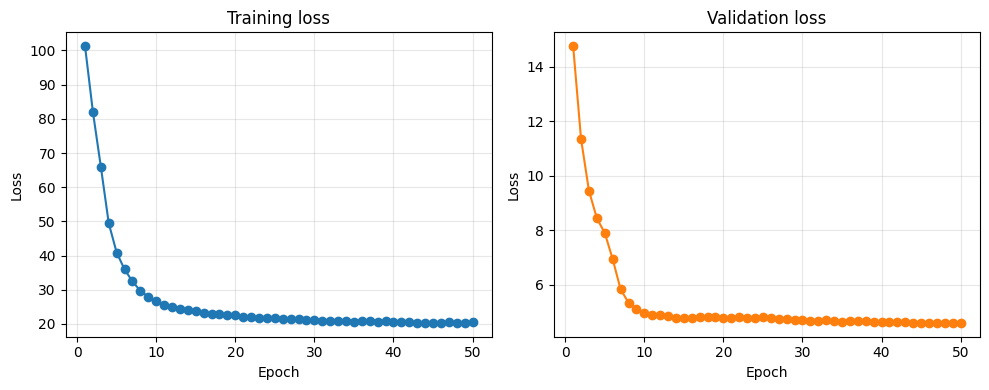

In [86]:
history = trainer.state.log_history
epoch_logs = [entry for entry in history if 'epoch' in entry]
train_epochs = [entry['epoch'] for entry in epoch_logs if 'loss' in entry]
train_loss = [entry['loss'] for entry in epoch_logs if 'loss' in entry]
eval_epochs = [entry['epoch'] for entry in epoch_logs if 'eval_loss' in entry]
eval_loss = [entry['eval_loss'] for entry in epoch_logs if 'eval_loss' in entry]

if not train_epochs and not eval_epochs:
    print('No training logs available for plotting.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    if train_epochs:
        axes[0].plot(train_epochs, train_loss, marker='o')
        axes[0].set_title('Training loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].axis('off')
        axes[0].text(0.5, 0.5, 'No training loss logs', ha='center', va='center')

    if eval_epochs:
        axes[1].plot(eval_epochs, eval_loss, marker='o', color='tab:orange')
        axes[1].set_title('Validation loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'No eval loss logs', ha='center', va='center')

    plt.tight_layout()
    plt.show()


## 9. Generate predictions

In [87]:
prediction_tokenizer = AutoTokenizer.from_pretrained(model_output_dir, use_fast=True)
prediction_model = AutoPeftModelForSeq2SeqLM.from_pretrained(model_output_dir)
prediction_model.to(DEVICE)
prediction_model.eval()

test_predictions = generate_predictions(
    working_test_rows,
    prediction_model,
    prediction_tokenizer,
    DEVICE,
    MAX_INPUT_LENGTH,
    MAX_TARGET_LENGTH,
    generation_config,
)

write_json(outputs_dir / 'test_predictions_cpu_v4.json', test_predictions)
print('Saved predictions:', outputs_dir / 'test_predictions_cpu_v4.json')
len(test_predictions)


Loading weights: 100%|██████████| 192/192 [00:00<00:00, 29278.54it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Saved predictions: d:\Pycharm projektai\Deep Learning Task 2\outputs\test_predictions_cpu_v4.json


61

## 10. Evaluate predictions

In [88]:
evaluation_report = evaluate_predictions(working_test_rows, test_predictions)
write_json(outputs_dir / 'evaluation_report_cpu_v4.json', evaluation_report)
{k: v for k, v in evaluation_report.items() if k != 'details'}


{'total_examples': 61,
 'exact_match': 0.0,
 'normalized_exact_match': 0.0,
 'average_char_similarity': 0.5866}

In [89]:
evaluation_report['details'][:5]

[{'id': 4,
  'informal_text': 'Atleido specialistus ir sukyšo savus kurie geležiinkelį matė tik kompe.',
  'gold': 'Atleido specialistus ir sukišo savus, kurie geležinkelį matę tik kompiuteryje.',
  'prediction': 'Atleido specialistus ir sukyšo savus kurie geležiinkelį matė tik kompe.',
  'exact_match': False,
  'normalized_exact_match': False,
  'char_similarity': 0.9128},
 {'id': 13,
  'informal_text': 'Sutapimai?? durpynas dega,dabar miskas,traukiniai nuo begiu..kas toliau?',
  'gold': 'Sutapimai? Durpynas dega, dabar miškas. Traukiniai nuo bėgių nurieda, kas toliau?',
  'prediction': 'Sutapimai? durpynas dega,dabar miskas,traukiniai nuo begiu.',
  'exact_match': False,
  'normalized_exact_match': False,
  'char_similarity': 0.7857},
 {'id': 14,
  'informal_text': 'Panašu į aktoriau kauke na',
  'gold': 'Panašu į aktoriaus kaukę.',
  'prediction': 'Panašu į aktoriau kauke natūrai. Panašu, į aktoriai kauke nai.',
  'exact_match': False,
  'normalized_exact_match': False,
  'char_simi

## 11. Test on a new input

In [90]:
demo_texts = [
    'nu ka cia dabar padarei',
    'gal galiu gauti greitesni atsakyma?',
    'siandien oras visai neblogas, ane?',
    'ta pati uzduoti jau trecia karta sprendziu',
    'galetum truputi aiskiau paaiskinti sita vieta',
]


In [91]:
for demo_text in demo_texts:
    demo_prompt = f"{PROMPT_PREFIX}\n\n{demo_text}"
    demo_encoded = prediction_tokenizer(demo_prompt, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LENGTH)
    demo_encoded = {key: value.to(DEVICE) for key, value in demo_encoded.items()}
    with torch.no_grad():
        demo_output_ids = prediction_model.generate(
            **demo_encoded,
            max_new_tokens=MAX_TARGET_LENGTH,
            **generation_config,
        )
    demo_prediction = prediction_tokenizer.decode(demo_output_ids[0], skip_special_tokens=True).strip()
    print('Input:', demo_text)
    print('Output:', demo_prediction)
    print('---')


Input: nu ka cia dabar padarei
Output: Tai ka cia dabar padarei. Nu ka čia dabar padarai.
---
Input: gal galiu gauti greitesni atsakyma?
Output: Kodėl galiu gauti greitesni atsakyma? gal galiu būti greitesnis atsakymas?
---
Input: siandien oras visai neblogas, ane?
Output: Šį oras visai neblogas, ane? Siandien oras visiškai neblogas.
---
Input: ta pati uzduoti jau trecia karta sprendziu
Output: Ta pati uzduoti jau trecia kartas sprendzi. Ta pati užduoti jau Trecia karta sprendziu.
---
Input: galetum truputi aiskiau paaiskinti sita vieta
Output: Kaip galetum truputi aiskiau paaiskinti sita vieta vieta.
---
